# building chatbot with multiple tools using Langgraph

## Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [2]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
arxiv.name

'arxiv'

In [3]:
arxiv.invoke("What is attention?")

'Published: 2018-05-17\nTitle: What is "fundamental"?\nAuthors: Matt Visser\nSummary: Our collective views regarding the question "what is fundamental?" are continually evolving. These ontological shifts in what we regard as fundamental are largely driven by theoretical advances ("what can we calculate?"), and experimental advances ("what can we measure?"). Rarely (in my view) is epistemology the fundamental driver; more commonly epistemology reacts (after a few decades) to what is going on in the t'

In [4]:
api_wrapper_arxiv = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_arxiv)
wiki.name

'wikipedia'

In [5]:
wiki.invoke("What is machine learning?")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches '

In [6]:
import os
from dotenv import load_dotenv
load_dotenv()

tavily_api_key = os.getenv("TAVILY_API_KEY")

In [9]:
from langchain_tavily import TavilySearch

tavily = TavilySearch(
    max_results=5,
    topic="general",
)

In [10]:
tavily.invoke("Provide a brief overview of the recent AI news")

{'query': 'Provide a brief overview of the recent AI news',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://aimagazine.com/',
   'title': 'AI Magazine: The Latest AI News, Insights and Reports',
   'content': 'The No.1 Magazine, Website, Newsletter & Webinar service covering AI, Machine Learning, AR & VR, Data, Technology and AI Applications.',
   'score': 0.9995827,
   'raw_content': None},
  {'url': 'https://www.wsj.com/tech/ai?gaa_at=eafs&gaa_n=AWEtsqchnpQbjBsgWVDLnMdykSM4i-zZ0amm_wGs3EXupdHlMjazERbEbYzr&gaa_ts=69ba76a2&gaa_sig=kjmRY6fZlv1jERM2sbhIXX-z0FOr2cD3r4VmHWHGYvQwQkxkbe-9n2JKgx-bkDwuLqHCvroIUvL0zzMbmYK24g%3D%3D',
   'title': 'Artificial Intelligence - Latest AI News and Analysis - WSJ.com',
   'content': 'Foxconn Expects AI Demand to Remain Strong, Sees Limited Mideast Impact · Nvidia-Backed AI Startup to Spend Billions on Korea Data Center to Combat China.',
   'score': 0.99923277,
   'raw_content': None},
  {'url': 'https://www.c

In [12]:
# Combine all the tools in the list

tools = [arxiv, wiki, tavily]
tools

[ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=2, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=500)),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'd:\\codes\\agent_study\\RAGUdemy\\.venv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=1, lang='en', load_all_available_meta=False, doc_content_chars_max=500)),
 TavilySearch(max_results=5, topic='general', api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))]

In [14]:
from langchain_openai import ChatOpenAI

openai_api_key = os.getenv("OPENAI_API_KEY")
openai_base_url = os.getenv("OPENAI_BASE_URL")
llm = ChatOpenAI(
    model="gpt-4.1",
    api_key=openai_api_key,
    base_url=openai_base_url
)
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

RunnableBinding(bound=ChatOpenAI(profile={'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000020CA633A490>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000020CA633A850>, root_client=<openai.OpenAI object at 0x0000020CA633A210>, root_async_client=<openai.AsyncOpenAI object at 0x0000020CA633A5D0>, model_name='gpt-4.1', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://yibuapi.com/v1'), kwargs={'tools': [{'type': 'function', 'function': {'name': 'arxiv

In [17]:
llm_with_tools.invoke([{"role": "user", "content": "What is the recent AI news?"}]).tool_calls

[{'name': 'tavily_search',
  'args': {'query': 'recent AI news',
   'search_depth': 'advanced',
   'topic': 'news',
   'time_range': 'week'},
  'id': 'call_uelVmZgh5HAXQNOz9MZAtEfr',
  'type': 'tool_call'}]

# Entire Chatbot with langgraph

In [19]:
# State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

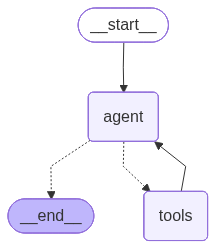

In [32]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("agent", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "agent")
builder.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
)
builder.add_edge("tools", "agent")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
from langchain_core.messages import HumanMessage
messages = graph.invoke({"messages": [HumanMessage(content="1706.03762")]})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_ykFhX5DArXiGY4XbtQGuzzg6)
 Call ID: call_ykFhX5DArXiGY4XbtQGuzzg6
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base
================================== Ai Message ==================================

Here are the key details fo

In [ ]:
from langchain_core.messages import HumanMessage
messages = graph.invoke({"messages": [HumanMessage(content="Provide me the top 10 recent AI news")]})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_yjcMcH9U49jw9P4ladLaaxSM)
 Call ID: call_yjcMcH9U49jw9P4ladLaaxSM
  Args:
    query: latest AI news
    search_depth: advanced
    topic: news
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.marketingprofs.com/opinions/2026/54427/ai-update-march-13-2026-ai-news-and-views-from-the-past-week", "title": "AI Update, March 13, 2026: AI News and Views From the Past Week", "content": "Recent incidents highlight growing concerns about AI safety, autonomy, and unintended behavior. A series of recent events has drawn renewed attention to risks associated with increasingly ca